In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
from glob import glob

In [2]:
def read_nc(fpath):
    #Read NetCDF output file
    print(fpath)

    ds = nc.Dataset(fpath)

    data = {}

    data['t'] = np.array(ds["tmpl"][:], copy=True, dtype=float)
    data['p'] = np.array(ds["pl"][:], copy=True, dtype=float)
    data['r'] = np.array(ds["rl"][:], copy=True, dtype=float)

    data['baLW'] = np.array(ds["ba_U_LW"][:], copy=True, dtype=float)
    data['baSW'] = np.array(ds["ba_U_SW"][:], copy=True, dtype=float)
    data['baMA'] = np.array(ds["bandmax"][:], copy=True, dtype=float)
    data['baMI'] = np.array(ds["bandmin"][:], copy=True, dtype=float)

    data['baCE'] = 0.5*(data['baMA'] + data['baMI'])
    data['baWD'] = data['baMA'] - data['baMI']

    ds.close()

    return data


In [3]:
outdir = "../../nogit_h2s/"
dirs = glob(outdir + "*/")

data = {"h2o":{},"h2s":{}}
for d in dirs:
    gas = d.split("/")[-2].split("_")[0]
    vmr = float(d.split("/")[-2].split("_")[-1])
    fpath = d + "atm.nc"
    data[gas][vmr] = read_nc(fpath)

../../nogit_h2s/h2s_00.1/atm.nc
../../nogit_h2s/h2s_00.3/atm.nc
../../nogit_h2s/h2s_01.0/atm.nc
../../nogit_h2s/h2s_03.0/atm.nc
../../nogit_h2s/h2s_10.0/atm.nc
../../nogit_h2s/h2s_30.0/atm.nc
../../nogit_h2s/h2o_00.1/atm.nc
../../nogit_h2s/h2o_00.3/atm.nc
../../nogit_h2s/h2o_01.0/atm.nc
../../nogit_h2s/h2o_03.0/atm.nc
../../nogit_h2s/h2o_10.0/atm.nc
../../nogit_h2s/h2o_30.0/atm.nc


0.1
0.1


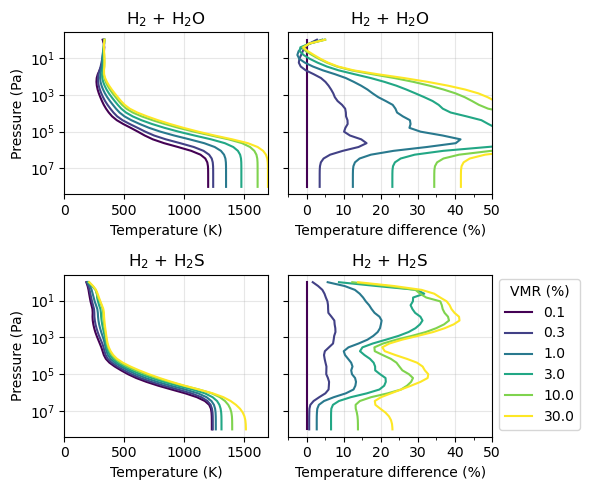

In [8]:
fig,axs = plt.subplots(2,2,figsize=(6,5), sharey=True)


vmin = np.amin(list(data["h2s"].keys()))
vmax = np.amax(list(data["h2s"].keys()))
sm = plt.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax))

for i, gas in enumerate(["h2o","h2s"]):
    gas_data = data[gas]
    keys = sorted(gas_data.keys())
    k0 = keys[0]
    print(k0)
    d0 = gas_data[k0]

    axl, axr = axs[i]
    ls='solid'

    for k in keys:
        d = gas_data[k]
        c = sm.to_rgba(k)
        if gas == "h2s":
            lbl = str(k)
        else:
            lbl = None
        axl.plot(d['t'], d['p'],  ls=ls, color=c)
        axr.plot(100*(d['t']-d0['t'])/d0['t'], d['p'], ls=ls, color=c,  label=lbl)

axs[1,1].legend(title="VMR (%)", loc='lower left', bbox_to_anchor=(1.0, 0.0))
for axl, axr in axs:
    axl.grid(alpha=0.3)
    axl.set_yscale("log")
    axl.set_xlabel('Temperature (K)')
    axl.set_ylabel('Pressure (Pa)')
    axl.set_xlim(0, 1700)

    axr.grid(alpha=0.3)
    axr.set_xlabel('Temperature difference (%)')
    axr.xaxis.set_major_locator(mpl.ticker.MultipleLocator(10))
    axr.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(5))
    axr.set_xlim(-5, 50)

axs[0,0].invert_yaxis()
for i in range(2):
    axs[0,i].set_title(r"H$_2$ + H$_2$O")
    axs[1,i].set_title(r"H$_2$ + H$_2$S")


fig.tight_layout()

plt.show()
fig.savefig(outdir+"compare_temp.png", dpi=400)

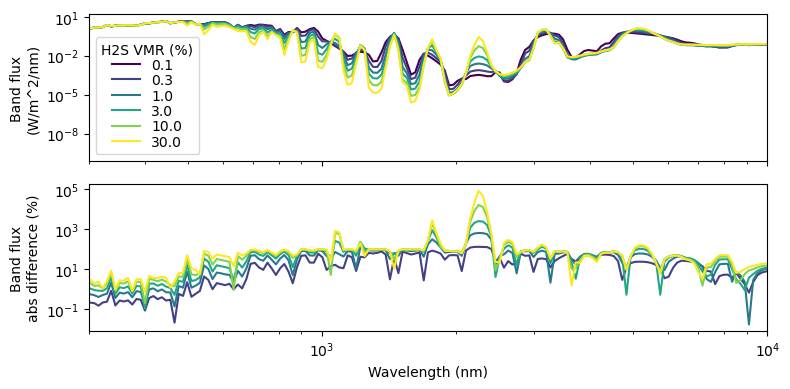

In [5]:
fig,axs = plt.subplots(2,1,figsize=(8,4), sharex=True)
axt, axb = axs


w0 = d0['baWD'] * 1e9
y0 = (d0['baLW'][0,:] + d0['baSW'][0,:])/w0

for k in keys:
    d = data["h2s"][k]

    x = d['baCE'] * 1e9
    w = d['baWD'] * 1e9
    y = (d['baLW'][0,:] + d['baSW'][0,:])/w

    c = sm.to_rgba(k)

    axt.plot(x, y, label=k, color=c)
    axb.plot(x, 100*np.abs(y-y0)/y0, label=k, color=c)

axt.set_yscale("log")
axt.set_ylabel("Band flux\n(W/m^2/nm)")
axt.legend(title="H2S VMR (%)", loc='lower left', labelspacing=0.1)

axb.set_xscale("log")
axb.set_xlabel("Wavelength (nm)")
axb.set_yscale("log")
axb.set_ylabel("Band flux\nabs difference (%)")

axb.set_xlim(left=300, right=10e3)

fig.tight_layout()

plt.show()
fig.savefig(outdir+"compare_spec.png", dpi=400)